<a href="https://colab.research.google.com/github/jdansb/Econophysics/blob/main/files/gas_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import numpy as np
N=1000 #quantidade de agentes
passos = 10000 #passos de monte carlo
tm = 9000 #A partir de qual passo coletar dados
res=[]  #resultados
m = np.array(N*[1.0]) #Dinheiro dos agentes
l= np.random.uniform(0, 1, size=N)
eta=[]
for t in range(passos):
  # Geramos os lambda e alphas
#  l= np.random.uniform(0, 1, size=N) #Se quisermos mudar lambda a cada passo
  a = np.random.uniform(0, 1, size=N)
  a = a / np.sum(a)
  #Copiamos o dinheiro atual
  m0=m.copy()

  #Geramos a fração da riqeuza monetária circulante
  #MV=0
  #for j in range(N):
  #    MV+=(1-l[j])*m0[j]

  #Atualizamos o dinheiro atual de cada agente
  for i in range(N):
    #m[i]=l[i]*m0[i]+a[i]*MV                      #Artigo 1
    m[i]=l[i]*m0[i]+np.random.normal(0, 0.01)   #Artigo 2

  #Então guardamos os dados
  if(t>=tm):
    res.extend(m)
    eta.append(MV*a[i])


In [77]:
from statsmodels.stats.diagnostic import acorr_ljungbox

janela=int(np.sqrt(len(eta)))

# teste de Ljung-Box
teste = acorr_ljungbox(eta, lags=[janela], return_df=True)

if (teste["lb_pvalue"].iloc[0]>0.05):
  print("Não há autocorrelação")
else:
  print("Há autocorrelação")


medias = []
desvios =[]

for i in range(0, len(x), janela):

    trecho = x[i:i+janela]

    medias.append(np.mean(trecho))
    desvios.append(np.std(trecho))
print("Razão entre desvio padrão e média da média:",np.std(medias)/np.mean(medias))
print("Razão entre desvio padrão e média do desvio:",np.std(desvios)/np.mean(desvios))

Não há autocorrelação
Razão entre desvio padrão e média da média: 0.08795338282318932
Razão entre desvio padrão e média do desvio: 0.1431722367058842


In [165]:
import matplotlib.pyplot as plt
a= np.array(res)  # Transformamos a lista em um array
ccfd = []  # Guardaremos as probabilidades
# Vamos definir que valores vamos pegar.
lim = 3
pts = 1000
x = np.logspace(0, lim, pts)
for i in x:  # Vamos percorrer todos os valores possíveis
    # Quantos agentes tem menos ou igual a i de moedas
    index = np.count_nonzero(a <= i)
    prob = 1-index/(len(res))  # A probabilidade de alguém ter mais que i
    ccfd.append(prob)  # Salvamos

In [27]:
np.std(desvios)

np.float64(0.12517635263184063)

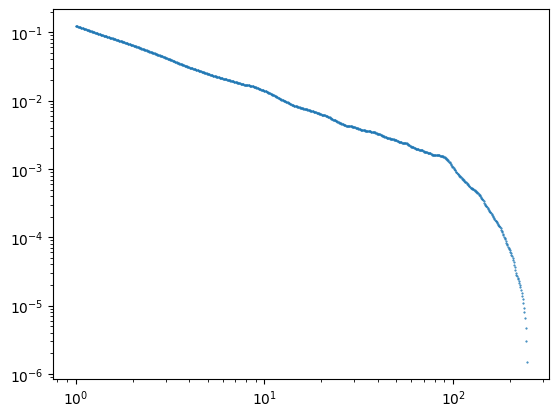

In [162]:

b = -(np.array(ccfd) == 0).sum() #Plotamos até  ter zero probabilidade
plt.plot(x[:b], ccfd[:b],'o', markersize=0.5)
plt.xscale("log")
plt.yscale("log")
#plt.xlim(8E-2,1E0)
#plt.plot(x, ccfd)


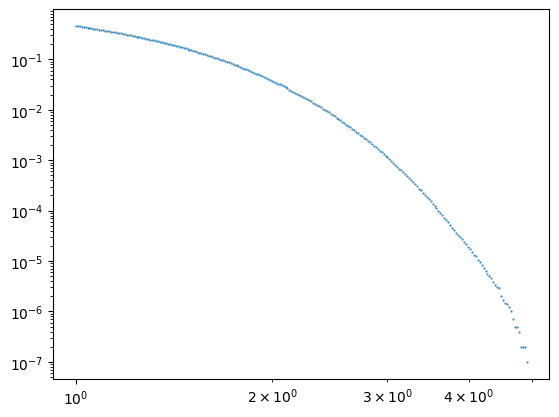

In [166]:

b = -(np.array(ccfd) == 0).sum() #Plotamos até  ter zero probabilidade
plt.plot(x[:b], ccfd[:b],'o', markersize=0.5)
plt.xscale("log")
plt.yscale("log")
#plt.xlim(8E-2,1E0)
#plt.plot(x, ccfd)


In [163]:
max(res)

np.float64(247.11915232276635)

In [97]:
ssum(m)

np.float64(100.00000000000003)

In [19]:
np.min(medias)

np.float64(0.41492031463115603)

In [30]:
import numpy as np
N=1000 #quantidade de agentes
passos = 10000 #passos de monte carlo
tm = 9000 #A partir de qual passo coletar dados
res=[]  #resultados
m = np.array(N*[1.0]) #Dinheiro dos agentes
l= np.random.uniform(0, 1, size=N)
eta=[]
for t in range(passos):
  # Geramos os lambda e alphas
  a = np.random.uniform(0, 1, size=N)
  a = a / np.sum(a)
  #Copiamos o dinheiro atual
  m0=m.copy()

  #Geramos a fração da riqeuza monetária circulante
  MV=0
  for j in range(N):
      MV+=(1-l[j])*m0[j]

  #Atualizamos o dinheiro atual de cada agente
  for i in range(N):
    m[i]=l[i]*m0[i]+a[i]*MV                      #Artigo 1

  #Então guardamos os dados
  if(t>=tm):
    res.extend(m)
    eta.append(MV)


99